In [2]:
import numpy as np, matplotlib.pyplot as plt, pandas as pd

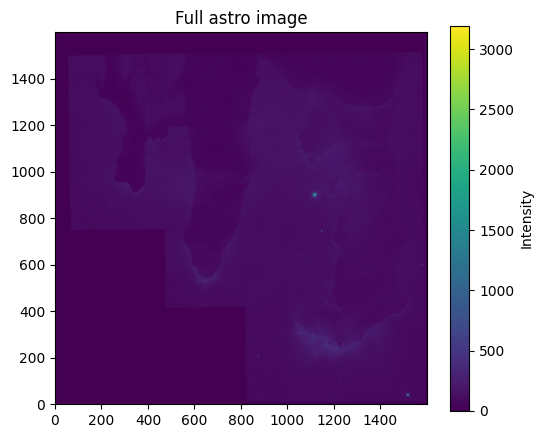

In [3]:
#3.1 plotting an astronomical image
data = np.loadtxt('astro_image.csv')
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(data, origin='lower', cmap='viridis')
fig.colorbar(im, ax=ax, label='Intensity')
ax.set_title('Full astro image')
plt.show()

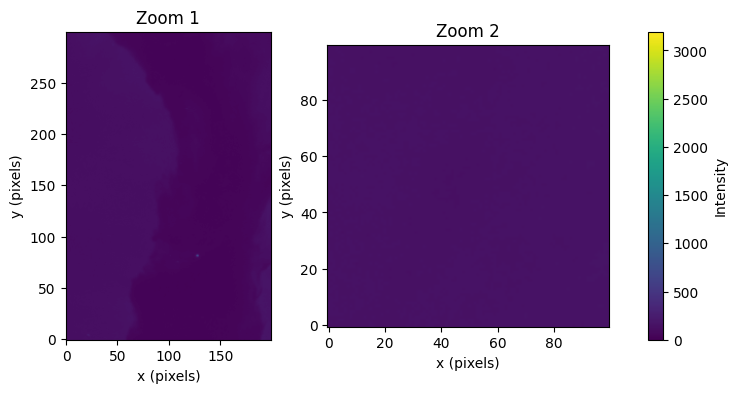

In [11]:
#choosing interesting region
r1, r2 = 1000, 1300
c1, c2 = 200, 400
zoom1 = data[r1:r2, c1:c2]
r3, r4 = 1050, 1150
c3, c4 = 900, 1000
zoom2 = data[r3:r4, c3:c4]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vmin = data.min()
vmax = data.max()

im1 = axes[0].imshow(zoom1, origin='lower', vmin=vmin, vmax=vmax)
axes[0].set_title('Zoom 1')
axes[0].set_xlabel('x (pixels)')
axes[0].set_ylabel('y (pixels)')

im2 = axes[1].imshow(zoom2, origin='lower', vmin=vmin, vmax=vmax)
axes[1].set_title('Zoom 2')
axes[1].set_xlabel('x (pixels)')
axes[1].set_ylabel('y (pixels)')

fig.colorbar(im1, ax=axes.ravel().tolist(), label='Intensity')

plt.show()

In [13]:
ramen = pd.read_csv('ramen-ratings.csv')
print(ramen.head)

<bound method NDFrame.head of       Review #           Brand  \
0         2580       New Touch   
1         2579        Just Way   
2         2578          Nissin   
3         2577         Wei Lih   
4         2576  Ching's Secret   
...        ...             ...   
2575         5           Vifon   
2576         4         Wai Wai   
2577         3         Wai Wai   
2578         2         Wai Wai   
2579         1        Westbrae   

                                                Variety Style   Country Stars  \
0                             T's Restaurant Tantanmen    Cup     Japan  3.75   
1     Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...  Pack    Taiwan     1   
2                         Cup Noodles Chicken Vegetable   Cup       USA  2.25   
3                         GGE Ramen Snack Tomato Flavor  Pack    Taiwan  2.75   
4                                       Singapore Curry  Pack     India  3.75   
...                                                 ...   ...       ...   .

In [14]:
ramen.columns

Index(['Review #', 'Brand', 'Variety', 'Style', 'Country', 'Stars', 'Top Ten'], dtype='object')

In [17]:
twentyseven = ramen.at[27, 'Style']
print(twentyseven)

Bowl


In [18]:
ramen['Brand'].nunique()

355

In [19]:
ramen_sorted = ramen.sort_values('Brand')

In [23]:
usa = ramen[ramen['Country'] == 'USA']['Brand'].nunique()
print(usa)

49


In [25]:
usa_pack = ramen[(ramen['Country'] == 'USA') & (ramen['Style'] == 'Pack')]['Brand'].nunique()
print(usa_pack)

27


In [36]:
from astropy.table import Table
t = Table.read('global_CCl4_MM.dat', format='ascii')

In [37]:
df = t['CCl4ottoyr', 'CCl4ottoGLm', 'CCl4ottoGLsd'].to_pandas()
print(df.head)

<bound method NDFrame.head of      CCl4ottoyr  CCl4ottoGLm  CCl4ottoGLsd
0          1996          NaN           NaN
1          1996          NaN           NaN
2          1996          NaN           NaN
3          1996      104.144         0.155
4          1996      103.893         0.174
..          ...          ...           ...
283        2019          NaN           NaN
284        2019          NaN           NaN
285        2019          NaN           NaN
286        2019          NaN           NaN
287        2019          NaN           NaN

[288 rows x 3 columns]>


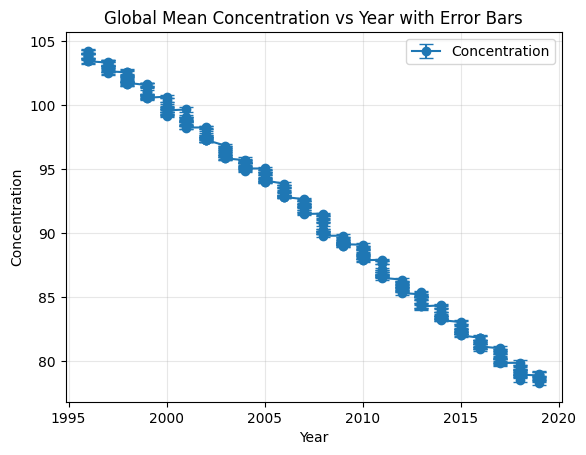

In [38]:
plt.errorbar(df['CCl4ottoyr'], df['CCl4ottoGLm'], yerr=df['CCl4ottoGLsd'], fmt='o-', capsize=5, label='Concentration')
plt.xlabel('Year')
plt.ylabel('Concentration')
plt.title('Global Mean Concentration vs Year with Error Bars')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
from scipy.stats import linregress

y = nanx + nan, R^2 = nan


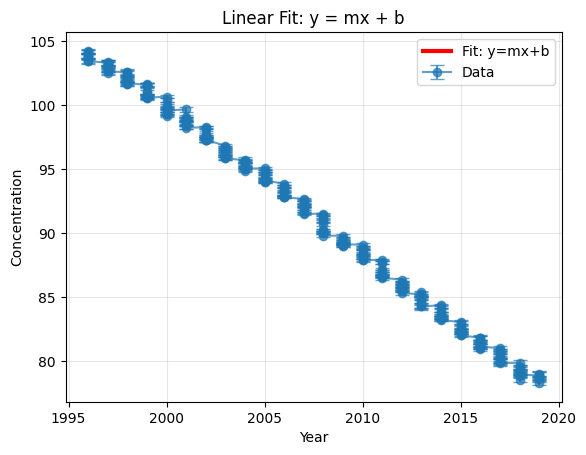

In [43]:
slope, intercept, r_value, p_value, std_err = linregress(df['CCl4ottoyr'], df['CCl4ottoGLm'])
print(f"y = {slope:.3f}x + {intercept:.3f}, R^2 = {r_value**2:.3f}")

plt.errorbar(df['CCl4ottoyr'], df['CCl4ottoGLm'], yerr=df['CCl4ottoGLsd'], fmt='o-', capsize=5, label='Data', alpha=0.7)
plt.plot(df['CCl4ottoyr'], slope*df['CCl4ottoyr'] + intercept, 'r-', linewidth=3, label='Fit: y=mx+b')
plt.xlabel('Year')
plt.ylabel('Concentration')
plt.title('Linear Fit: y = mx + b')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [44]:
model = slope * df['CCl4ottoyr'] + intercept
residuals = (df['CCl4ottoGLm'] - model) / df['CCl4ottoGLsd']
chi2 = np.sum(residuals**2)
dof = len(df) - 2
reduced_chi2 = chi2 / dof
print(f"χ² = {chi2:.3f}, Reduced χ² = {reduced_chi2:.3f} (dof={dof})")

χ² = 0.000, Reduced χ² = 0.000 (dof=286)


In [46]:
#I'm pretty sure something went wrong while plotting it to begin with...
#Hence the weird chi-square value